# Along track distance

In [1]:
# %load_ext autoreload
# %autoreload 2


import geopandas as gpd
import pandas as pd

import airbornegeo

In [2]:
data_df = pd.read_csv("data/AGAP_gravity_survey_processed.csv")
data_df = data_df[["easting", "northing", "line", "unixtime"]]
# for speed only retain every 10th point
data_df = data_df[::10]
data_df

,easting,northing,line,unixtime
0,1.000024e+06,226237.330771,1,1.229507e+09
10,1.000613e+06,226327.808992,1,1.229507e+09
20,1.001192e+06,226414.710863,1,1.229507e+09
30,1.001780e+06,226511.084361,1,1.229507e+09
40,1.002378e+06,226611.524394,1,1.229507e+09
...,...,...,...,...
333950,1.587614e+06,498482.478462,100,1.230382e+09
333960,1.587703e+06,497964.301966,100,1.230382e+09
333970,1.587793e+06,497444.869696,100,1.230382e+09
333980,1.587891e+06,496927.693234,100,1.230382e+09


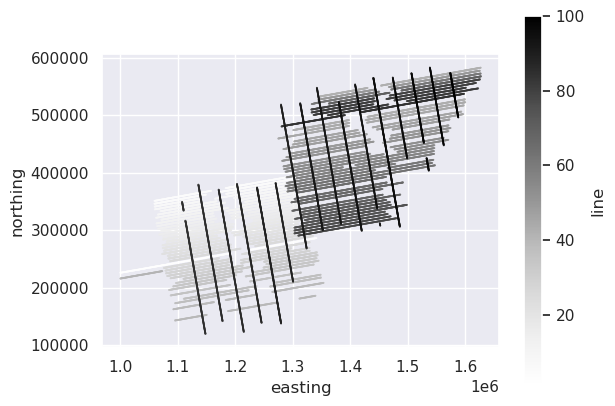

In [3]:
# plot the survey colored by line number
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="line",
    s=0.1,
)
ax.set_aspect("equal")

## Sort by time (and line)

The `along_track_distance` function assumes the data have been sorted by ascending time. If you have lines which overlap in time, then the data should first be sorted by the column which has the line names, and then by time.

In [4]:
data_df = data_df.sort_values(["line", "unixtime"])
data_df

,easting,northing,line,unixtime
0,1.000024e+06,226237.330771,1,1.229507e+09
10,1.000613e+06,226327.808992,1,1.229507e+09
20,1.001192e+06,226414.710863,1,1.229507e+09
30,1.001780e+06,226511.084361,1,1.229507e+09
40,1.002378e+06,226611.524394,1,1.229507e+09
...,...,...,...,...
333950,1.587614e+06,498482.478462,100,1.230382e+09
333960,1.587703e+06,497964.301966,100,1.230382e+09
333970,1.587793e+06,497444.869696,100,1.230382e+09
333980,1.587891e+06,496927.693234,100,1.230382e+09


## Along track distance per line

By passing the column name "line" to `groupby_column` the distances will start at 0 for each line. 

Segments:   0%|          | 0/100 [00:00<?, ?it/s]

,easting,northing,line,unixtime,line_distance
0,1.000024e+06,226237.330771,1,1.229507e+09,0.000000
10,1.000613e+06,226327.808992,1,1.229507e+09,595.832558
20,1.001192e+06,226414.710863,1,1.229507e+09,1181.732288
30,1.001780e+06,226511.084361,1,1.229507e+09,1777.621139
40,1.002378e+06,226611.524394,1,1.229507e+09,2384.001211


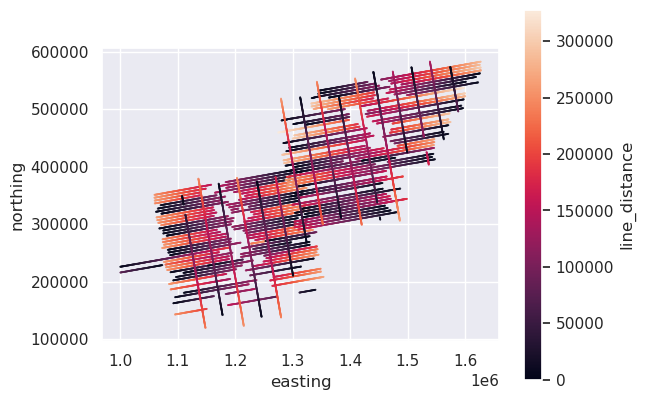

In [5]:
data_df["line_distance"] = airbornegeo.along_track_distance(
    data_df,
    groupby_column="line",
)

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="line_distance",
    s=0.1,
)
ax.set_aspect("equal")

data_df.head()

## Along track distance for the whole survey

Without passing `groupby_column`, the dataframe will be treated as a single segment, and distance will be along track, relative to the first row.

,easting,northing,line,unixtime,line_distance,survey_distance
0,1.000024e+06,226237.330771,1,1.229507e+09,0.000000,0.000000
10,1.000613e+06,226327.808992,1,1.229507e+09,595.832558,595.832558
20,1.001192e+06,226414.710863,1,1.229507e+09,1181.732288,1181.732288
30,1.001780e+06,226511.084361,1,1.229507e+09,1777.621139,1777.621139
40,1.002378e+06,226611.524394,1,1.229507e+09,2384.001211,2384.001211


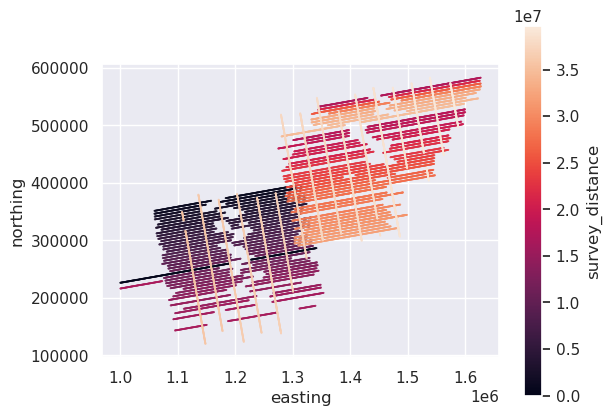

In [6]:
data_df["survey_distance"] = airbornegeo.along_track_distance(
    data_df,
)

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="survey_distance",
    s=0.1,
)
ax.set_aspect("equal")

data_df.head()

## Distances without time data
The above functions assume the data is sorted by time. If you don't have time data, but your data is still sorted by time, the functions will work. If you are unsure if your data is sorted by time, then you can use set `guess_start_position` to `True`. This will use which ever end of the segment is furthest west as the starting point and calculate distances relative to that point. 

In [7]:
# un-sort the data to demonstrate
unsorted_data_df = data_df.sample(frac=1).reset_index(drop=True)
unsorted_data_df.head()

,easting,northing,line,unixtime,line_distance,survey_distance
0,1.285251e+06,326565.153220,16,1.230550e+09,213984.660343,6.595644e+06
1,1.604786e+06,568877.122085,61,1.230832e+09,276239.083511,2.614269e+07
2,1.435559e+06,358241.772179,69,1.231326e+09,21436.204849,2.884999e+07
3,1.389081e+06,425112.905095,54,1.230056e+09,184471.323225,2.358098e+07
4,1.262701e+06,234922.616264,89,1.229610e+09,141821.591929,3.681556e+07


Segments:   0%|          | 0/100 [00:00<?, ?it/s]

,easting,northing,line,unixtime,line_distance,survey_distance,geometry
0,1.000024e+06,226237.330771,1,1.229507e+09,0.000000,0.000000,POINT (1000023.79 226237.331)
10,1.000613e+06,226327.808992,1,1.229507e+09,595.832558,595.832558,POINT (1000612.713 226327.809)
20,1.001192e+06,226414.710863,1,1.229507e+09,1181.732288,1181.732288,POINT (1001192.132 226414.711)
30,1.001780e+06,226511.084361,1,1.229507e+09,1777.621139,1777.621139,POINT (1001780.176 226511.084)
40,1.002378e+06,226611.524394,1,1.229507e+09,2384.001211,2384.001211,POINT (1002378.18 226611.524)


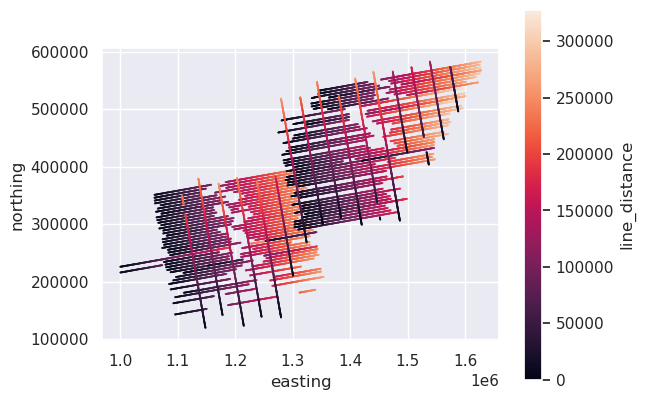

In [10]:
# for this method, we need a geodataframe
unsorted_data_df = gpd.GeoDataFrame(
    unsorted_data_df,
    geometry=gpd.points_from_xy(unsorted_data_df.easting, unsorted_data_df.northing),
    crs="EPSG:3031",
)
unsorted_data_df["line_distance"] = airbornegeo.along_track_distance(
    unsorted_data_df,
    groupby_column="line",
    guess_start_position=True,
)

ax = unsorted_data_df.plot.scatter(
    "easting",
    "northing",
    c="line_distance",
    s=0.1,
)
ax.set_aspect("equal")

unsorted_data_df.head()